# Emotion Semantic Network Visualization
This notebook creates visualizations for emotion relationships including:
- Binary relationship table
- Detailed relationship table
- Network graph visualization

## Cell 1: Imports and Setup

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Create undirected graph for bidirectional visualization
G = nx.Graph()

# Add nodes
nodes = ["joy", "sadness", "anger", "fear", "love", "surprise"]
G.add_nodes_from(nodes)

print("Setup complete!")
print(f"Nodes: {nodes}")

Setup complete!
Nodes: ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']


## Cell 2: Define Relations

In [2]:
# Enhanced relations from LLM with better semantic coverage
relations = [
    # Opposite relationships (bidirectional)
    ("sadness", "OPPOSITE_OF", "joy"),
    ("anger", "OPPOSITE_OF", "love"),
    ("fear", "OPPOSITE_OF", "surprise"),

    # Hierarchical relationships (directional)
    ("joy", "IS_A", "love"),
    ("anger", "IS_A", "sadness"),

    # Causal relationships (directional)
    ("anger", "CAUSES", "sadness"),
    ("joy", "CAUSES", "surprise"),
    ("love", "CAUSES", "joy"),
    ("fear", "CAUSES", "anger"),

    # Triggering relationships (directional)
    ("fear", "TRIGGERS", "anger"),
    ("surprise", "TRIGGERS", "joy"),
    ("surprise", "TRIGGERS", "fear"),
    ("sadness", "TRIGGERS", "anger"),

    # Mitigation/Suppression relationships (directional)
    ("love", "MITIGATES", "fear"),
    ("love", "MITIGATES", "sadness"),
    ("joy", "SUPPRESSES", "sadness"),
    ("joy", "SUPPRESSES", "anger"),

    # Co-occurrence relationships (bidirectional)
    ("fear", "COEXISTS_WITH", "sadness"),
    ("anger", "COEXISTS_WITH", "sadness"),

    # Transition relationships (directional)
    ("anger", "LEADS_TO", "sadness"),
    ("fear", "LEADS_TO", "sadness"),
    ("surprise", "LEADS_TO", "joy"),

    # Similar/Related relationships (bidirectional)
    ("joy", "SIMILAR_TO", "love"),
    ("anger", "SIMILAR_TO", "fear"),
]

# Define which relationships are bidirectional
bidirectional_relations = {
    "OPPOSITE_OF", "COEXISTS_WITH", "SIMILAR_TO"
}

# Add relationships with bidirectional handling
for node1, relation, node2 in relations:
    is_bidirectional = relation in bidirectional_relations
    G.add_edge(node1, node2, relation=relation, bidirectional=is_bidirectional)

print(f"Total nodes: {len(nodes)}")
print(f"Total relationships: {len(relations)}")
print(f"Bidirectional relationships: {len([r for r in relations if r[1] in bidirectional_relations])}")
print(f"Directional relationships: {len([r for r in relations if r[1] not in bidirectional_relations])}")

Total nodes: 6
Total relationships: 24
Bidirectional relationships: 7
Directional relationships: 17


## Cell 3: Create Binary Relationship Matrix

In [3]:
# Create empty matrix
matrix = pd.DataFrame(0, index=nodes, columns=nodes)

# Fill matrix with relationship counts
for node1, relation, node2 in relations:
    is_bidirectional = relation in bidirectional_relations
    matrix.loc[node1, node2] = 1
    if is_bidirectional:
        matrix.loc[node2, node1] = 1

print("RELATIONSHIP MATRIX (1 = Related, 0 = Not Related)")
print(matrix)

RELATIONSHIP MATRIX (1 = Related, 0 = Not Related)
          joy  sadness  anger  fear  love  surprise
joy         0        1      1     0     1         1
sadness     1        0      1     1     0         0
anger       0        1      0     1     1         0
fear        0        1      1     0     0         1
love        1        1      1     1     0         0
surprise    1        0      0     1     0         0


## Cell 4: Create Detailed Relationship Matrix

In [4]:
# Create matrix with relationship types
detailed_matrix = pd.DataFrame("", index=nodes, columns=nodes)

for node1, relation, node2 in relations:
    is_bidirectional = relation in bidirectional_relations

    # For source -> target
    if detailed_matrix.loc[node1, node2] == "":
        detailed_matrix.loc[node1, node2] = relation
    else:
        detailed_matrix.loc[node1, node2] += f", {relation}"

    # For bidirectional, add reverse
    if is_bidirectional:
        if detailed_matrix.loc[node2, node1] == "":
            detailed_matrix.loc[node2, node1] = relation
        else:
            detailed_matrix.loc[node2, node1] += f", {relation}"

print("DETAILED RELATIONSHIP MATRIX (Showing Relationship Types)")
print(detailed_matrix)

DETAILED RELATIONSHIP MATRIX (Showing Relationship Types)
                         joy                                sadness  \
joy                                         OPPOSITE_OF, SUPPRESSES   
sadness          OPPOSITE_OF                                          
anger                         IS_A, CAUSES, COEXISTS_WITH, LEADS_TO   
fear                                        COEXISTS_WITH, LEADS_TO   
love      CAUSES, SIMILAR_TO                              MITIGATES   
surprise  TRIGGERS, LEADS_TO                                          

                                 anger                   fear  \
joy                         SUPPRESSES                          
sadness        TRIGGERS, COEXISTS_WITH          COEXISTS_WITH   
anger                                              SIMILAR_TO   
fear      CAUSES, TRIGGERS, SIMILAR_TO                          
love                       OPPOSITE_OF              MITIGATES   
surprise                                OPPOSITE_OF, T

## Cell 5: Visualize Binary Relationship Table

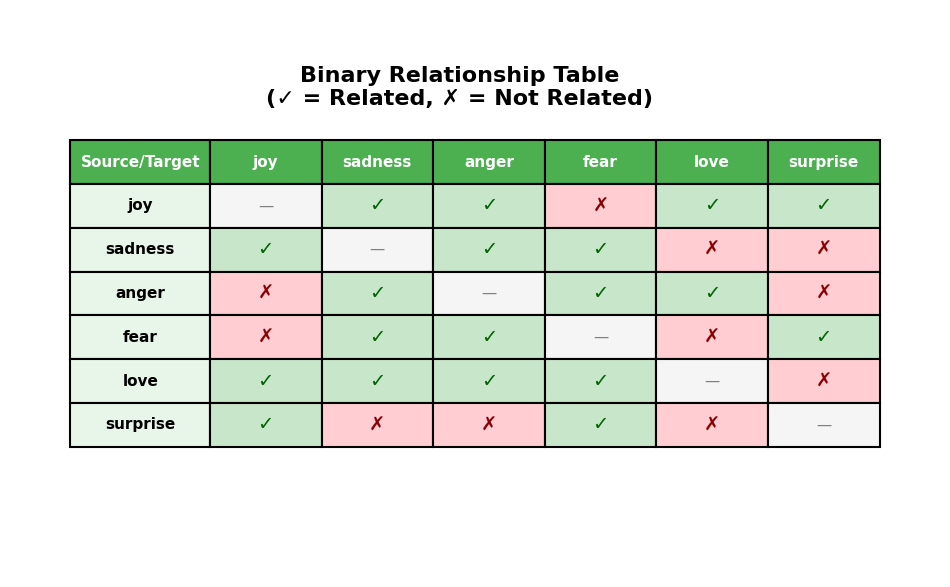

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = []
for idx in matrix.index:
    row = [idx]
    for col in matrix.columns:
        if idx == col:
            row.append("—")
        elif matrix.loc[idx, col] == 1:
            row.append("✓")
        else:
            row.append("✗")
    table_data.append(row)

# Create the table
table = ax.table(cellText=table_data,
                colLabels=['Source/Target'] + list(matrix.columns),
                cellLoc='center',
                loc='center',
                colWidths=[0.15] + [0.12]*len(matrix.columns))

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style the table
for i in range(len(table_data) + 1):
    for j in range(len(matrix.columns) + 1):
        cell = table[(i, j)]

        if i == 0:  # Header row
            cell.set_facecolor('#4CAF50')
            cell.set_text_props(weight='bold', color='white')
        elif j == 0:  # First column
            cell.set_facecolor('#E8F5E9')
            cell.set_text_props(weight='bold')
        else:
            # Color cells based on content
            text = cell.get_text().get_text()
            if text == "✓":
                cell.set_facecolor('#C8E6C9')
                cell.set_text_props(color='darkgreen', weight='bold', size=14)
            elif text == "✗":
                cell.set_facecolor('#FFCDD2')
                cell.set_text_props(color='darkred', weight='bold', size=14)
            else:  # "—"
                cell.set_facecolor('#F5F5F5')
                cell.set_text_props(color='gray')

        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)

plt.suptitle('Binary Relationship Table\n(✓ = Related, ✗ = Not Related)',
          fontsize=16, fontweight='bold', y=0.84)
plt.subplots_adjust(top=0.92)
plt.show()

## Cell 6: Visualize Detailed Relationship Table

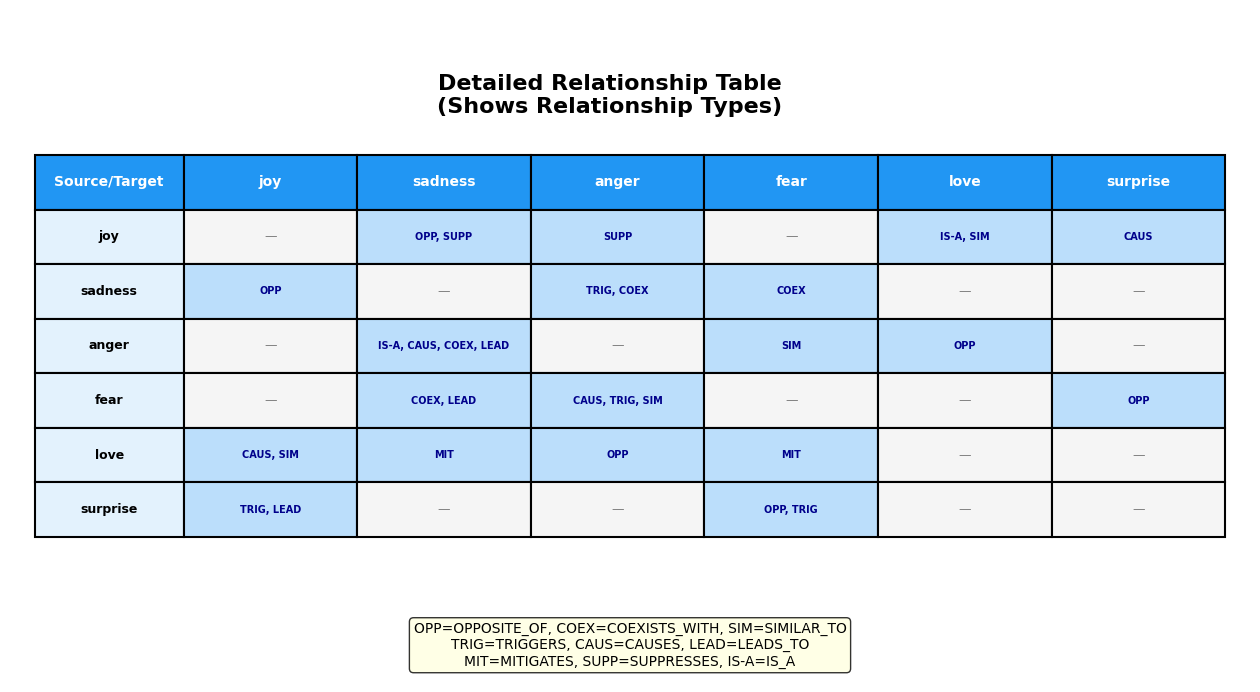

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Create detailed table data
detailed_table_data = []
for idx in detailed_matrix.index:
    row = [idx]
    for col in detailed_matrix.columns:
        if idx == col:
            row.append("—")
        elif detailed_matrix.loc[idx, col] != "":
            # Shorten for table display
            rels = detailed_matrix.loc[idx, col]
            rels_short = rels.replace("OPPOSITE_OF", "OPP").replace("COEXISTS_WITH", "COEX")
            rels_short = rels_short.replace("SIMILAR_TO", "SIM").replace("TRIGGERS", "TRIG")
            rels_short = rels_short.replace("SUPPRESSES", "SUPP").replace("MITIGATES", "MIT")
            rels_short = rels_short.replace("LEADS_TO", "LEAD").replace("CAUSES", "CAUS")
            rels_short = rels_short.replace("IS_A", "IS-A")
            row.append(rels_short)
        else:
            row.append("—")
    detailed_table_data.append(row)

# Create the detailed table
detailed_table = ax.table(cellText=detailed_table_data,
                         colLabels=['Source/Target'] + list(detailed_matrix.columns),
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.12] + [0.14]*len(detailed_matrix.columns))

detailed_table.auto_set_font_size(False)
detailed_table.set_fontsize(8)
detailed_table.scale(1, 3)

# Style the detailed table
for i in range(len(detailed_table_data) + 1):
    for j in range(len(detailed_matrix.columns) + 1):
        cell = detailed_table[(i, j)]

        if i == 0:  # Header row
            cell.set_facecolor('#2196F3')
            cell.set_text_props(weight='bold', color='white', size=10)
        elif j == 0:  # First column
            cell.set_facecolor('#E3F2FD')
            cell.set_text_props(weight='bold', size=9)
        else:
            # Color cells based on content
            text = cell.get_text().get_text()
            if text != "—":
                cell.set_facecolor('#BBDEFB')
                cell.set_text_props(color='darkblue', weight='bold', size=7)
            else:
                cell.set_facecolor('#F5F5F5')
                cell.set_text_props(color='gray', size=9)

        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)

plt.suptitle('Detailed Relationship Table\n(Shows Relationship Types)',
          fontsize=16, fontweight='bold', y=0.84)

# Add legend at bottom
legend_text = ("OPP=OPPOSITE_OF, COEX=COEXISTS_WITH, SIM=SIMILAR_TO\n"
              "TRIG=TRIGGERS, CAUS=CAUSES, LEAD=LEADS_TO\n"
              "MIT=MITIGATES, SUPP=SUPPRESSES, IS-A=IS_A")
plt.text(0.5, 0.02, legend_text, transform=ax.transAxes,
        fontsize=10, ha='center', va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.subplots_adjust(top=0.92, bottom=0.08)
plt.show()

## Cell 7: Visualize Network Graph

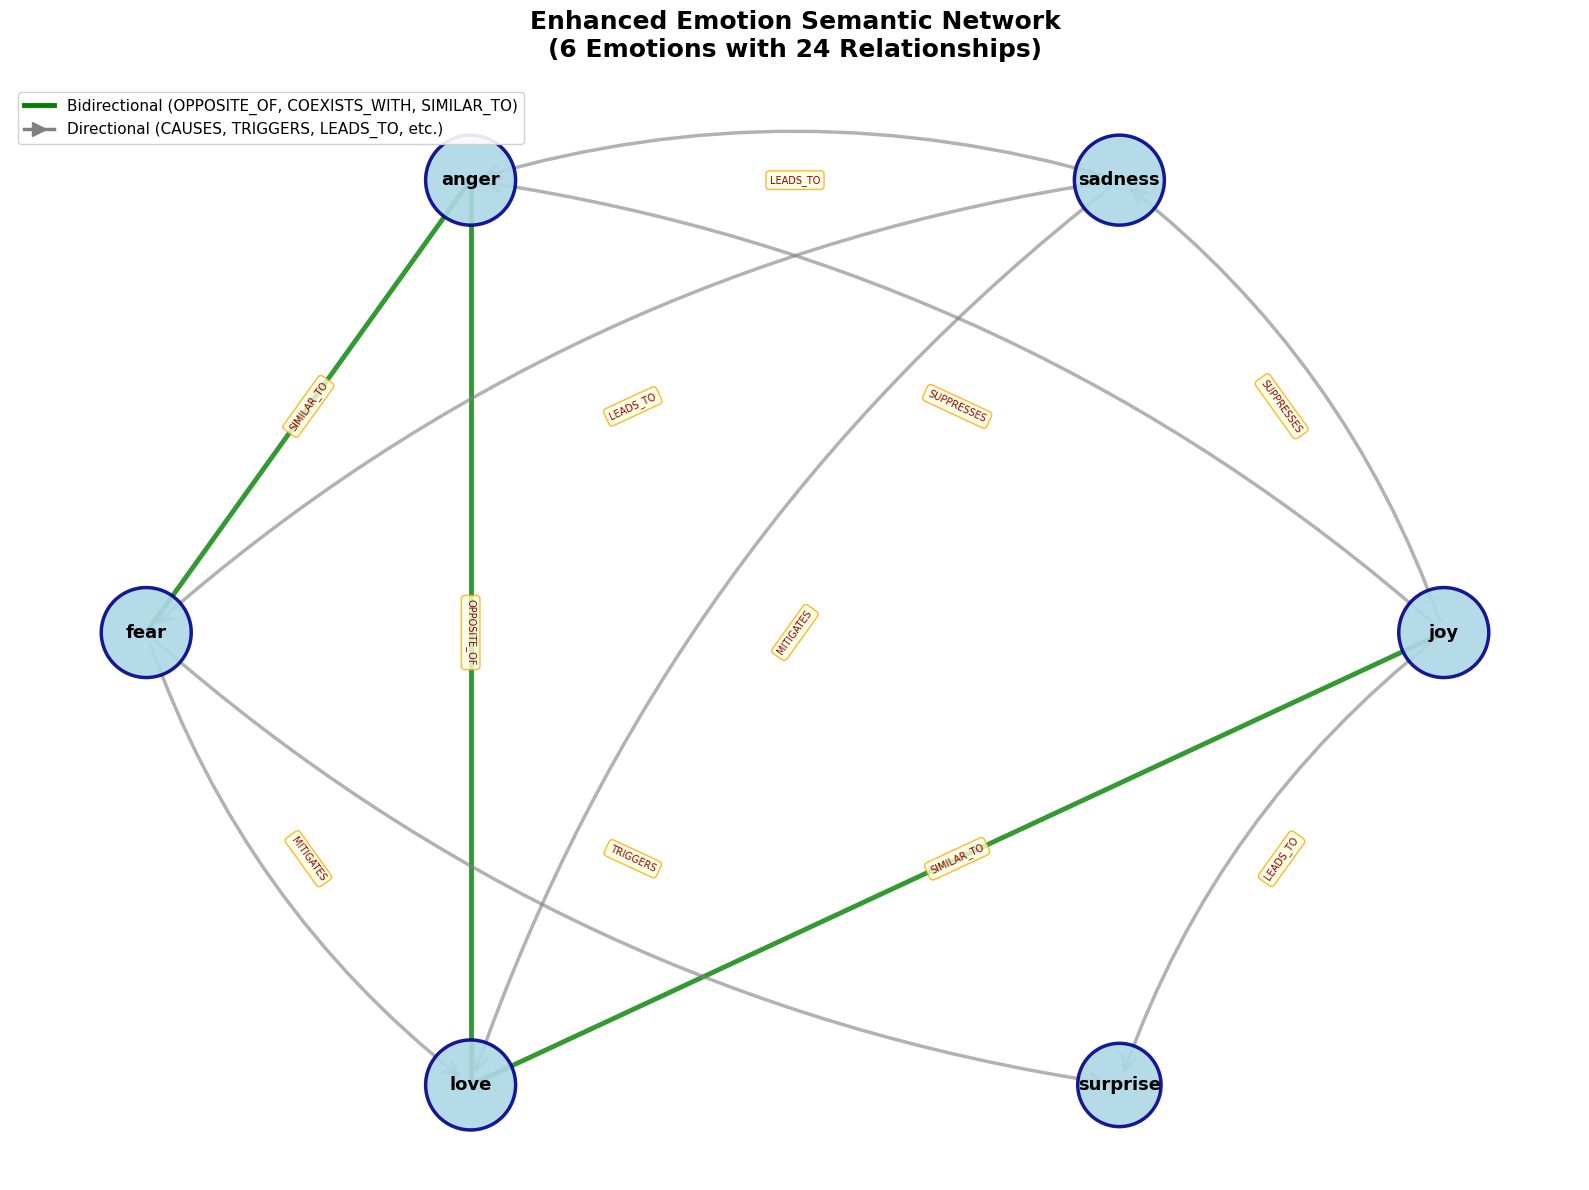

In [7]:
np.random.seed(42)

plt.figure(figsize=(16, 12))

# Use a fixed circular layout for stability
pos = nx.circular_layout(G)

# OR use spring layout with a FIXED seed for reproducibility
# pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)

# Draw nodes with different sizes based on degree
node_sizes = [3000 + G.degree(node) * 300 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color="lightblue",
                       node_size=node_sizes, alpha=0.9,
                       edgecolors='darkblue', linewidths=2.5)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold', font_family='sans-serif')

# Separate edges by type
bidirectional_edges = [(u, v) for u, v, d in G.edges(data=True)
                       if d.get('bidirectional', False)]
directional_edges = [(u, v) for u, v, d in G.edges(data=True)
                     if not d.get('bidirectional', False)]

# Draw bidirectional edges (thicker, green)
nx.draw_networkx_edges(G, pos, edgelist=bidirectional_edges,
                       width=3.5, alpha=0.8, edge_color='green',
                       style='solid', arrows=False)

# Draw directional edges with arrows
nx.draw_networkx_edges(G, pos, edgelist=directional_edges,
                       width=2.5, alpha=0.6, edge_color='gray',
                       style='solid', arrows=True,
                       arrowsize=25, arrowstyle='->',
                       connectionstyle='arc3,rad=0.15')

# Draw edge labels with better formatting
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=7, font_color='darkred',
                              bbox=dict(boxstyle='round,pad=0.4',
                                       facecolor='lightyellow',
                                       edgecolor='orange',
                                       alpha=0.8))

plt.title("Enhanced Emotion Semantic Network\n(6 Emotions with 24 Relationships)",
          fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=3.5, label='Bidirectional (OPPOSITE_OF, COEXISTS_WITH, SIMILAR_TO)'),
    Line2D([0], [0], color='gray', linewidth=2.5, label='Directional (CAUSES, TRIGGERS, LEADS_TO, etc.)',
           marker='>', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

plt.show()

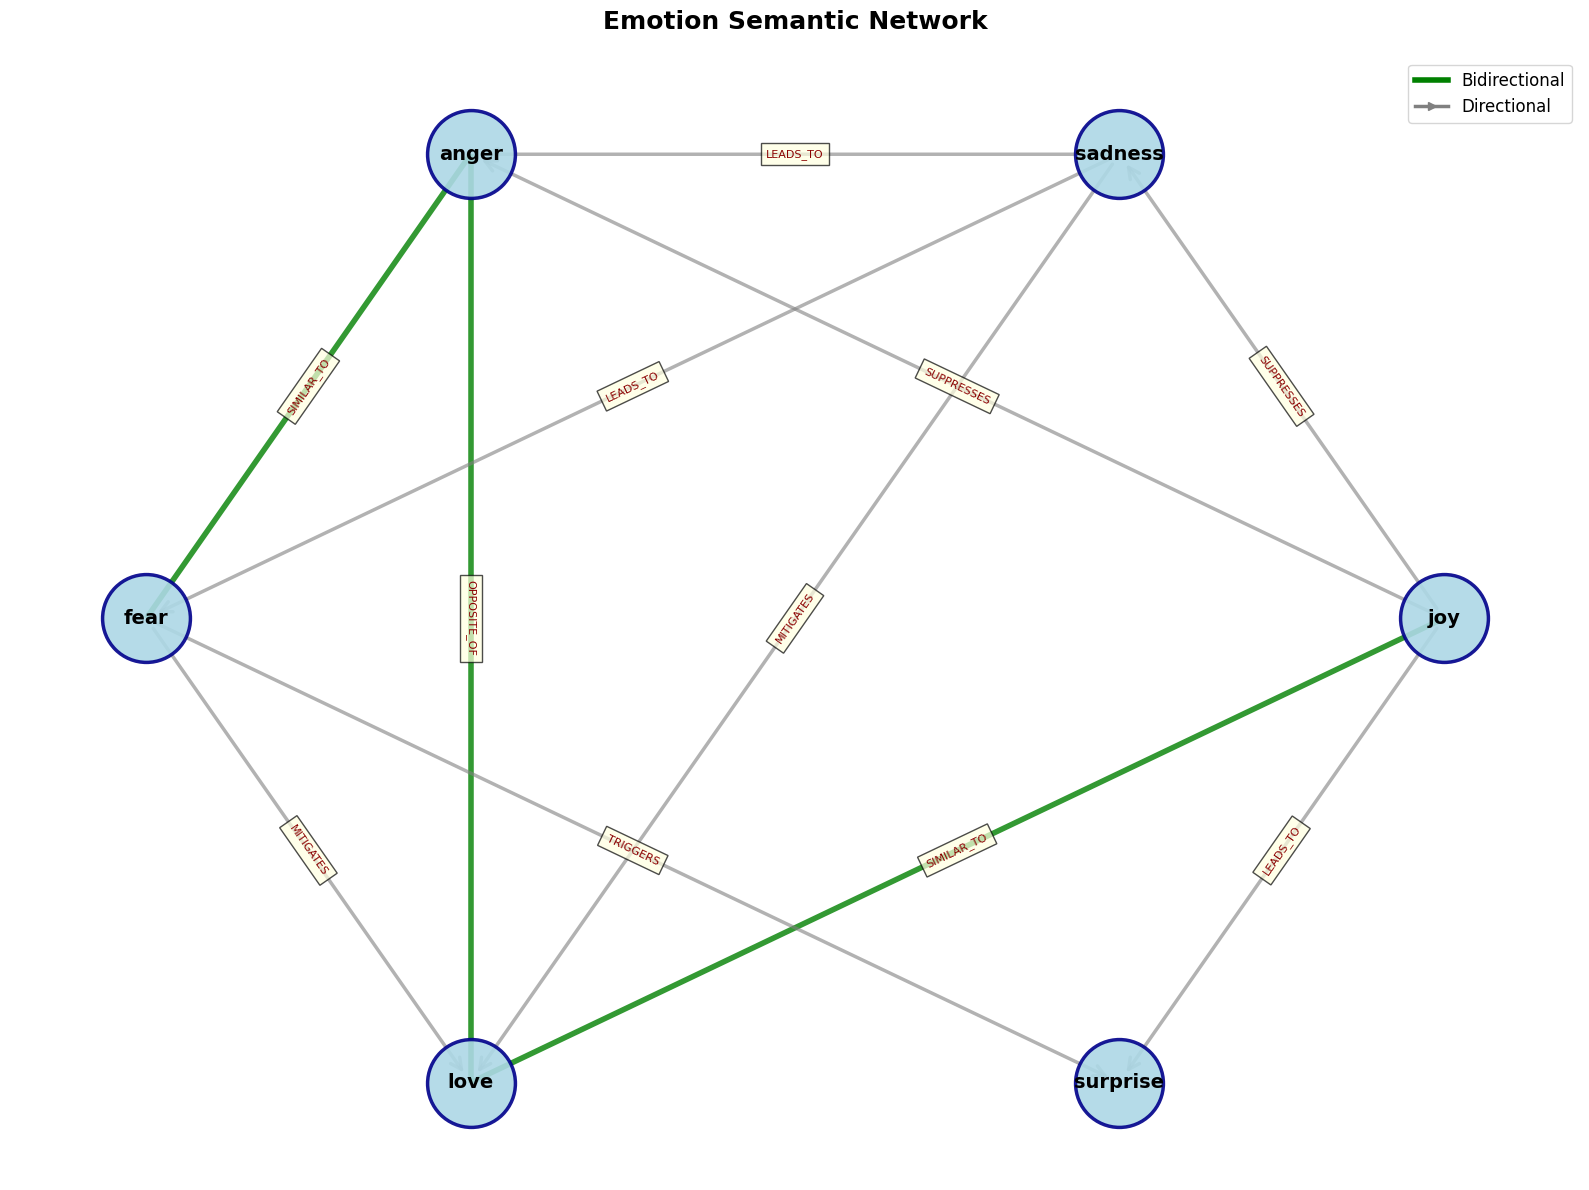

In [8]:
import numpy as np
np.random.seed(42)

plt.figure(figsize=(16, 12))

# Use circular layout - ALWAYS STABLE
pos = nx.circular_layout(G)

# Draw nodes with fixed size
nx.draw_networkx_nodes(G, pos, node_color="lightblue",
                       node_size=4000, alpha=0.9,
                       edgecolors='darkblue', linewidths=2.5)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Separate edges by type
bidirectional_edges = [(u, v) for u, v, d in G.edges(data=True)
                       if d.get('bidirectional', False)]
directional_edges = [(u, v) for u, v, d in G.edges(data=True)
                     if not d.get('bidirectional', False)]

# Draw bidirectional edges (green, no arrows)
nx.draw_networkx_edges(G, pos, edgelist=bidirectional_edges,
                       width=4, alpha=0.8, edge_color='green')

# Draw directional edges (gray, with arrows)
nx.draw_networkx_edges(G, pos, edgelist=directional_edges,
                       width=2.5, alpha=0.6, edge_color='gray',
                       arrows=True, arrowsize=20, arrowstyle='->')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=8, font_color='darkred',
                              bbox=dict(facecolor='lightyellow', alpha=0.7))

plt.title("Emotion Semantic Network", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=4, label='Bidirectional'),
    Line2D([0], [0], color='gray', linewidth=2.5, label='Directional', marker='>')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.show()